In [ ]:
# 시각화 라이브러리
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 처리
import pandas as pd
import numpy as np

# 펭귄 데이터 불러오기
df = sns.load_dataset("penguins")


# 상위 5개 출력
print(df.head())

# df.to_excel("펭귄.xlsx")

# species → 펭귄 종류 (목표 확인용)
# island → 서식 섬
# bill_length_mm → 부리 길이
# bill_depth_mm → 부리 깊이
# flipper_length_mm → 날개 길이
# body_mass_g → 몸무게
# sex → 성별

In [ ]:
df.info()
print(df.isnull().sum())

In [ ]:
# 결측치 제거
# 수치형만 보기 위해 제거해 버림
df = df.dropna()
df.info()

In [ ]:
# 수치 컬럼만 선택
num_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# 히스토그램
df[num_cols].hist(
    figsize=(10,8)
)

plt.show()

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


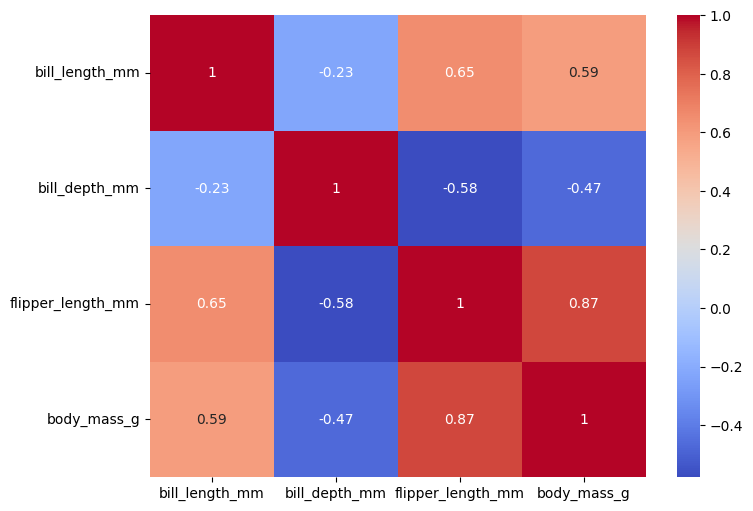

In [35]:
# 상관계수 계산
corr = df[num_cols].corr()

print(corr)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler

# 입력 데이터 선택
X = df[num_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[-0.89604189  0.7807321  -1.42675157 -0.56847478]
 [-0.82278787  0.11958397 -1.06947358 -0.50628618]
 [-0.67627982  0.42472926 -0.42637319 -1.1903608 ]
 [-1.33556603  1.0858774  -0.56928439 -0.94160639]
 [-0.85941488  1.74702554 -0.78365118 -0.69285199]]


In [37]:
# PCA 수행
from sklearn.decomposition import PCA

# 2차원 축소
pca = PCA(n_components=2)
# PCA 적용
X_pca = pca.fit_transform(X_scaled)
print(X_pca[:5])

[[-1.85359302  0.03206938]
 [-1.31625406 -0.44352677]
 [-1.37660509 -0.16123048]
 [-1.88528838 -0.01235124]
 [-1.91998074  0.81759813]]


In [ ]:
print(pca.explained_variance_ratio_)
# 설명력은 89% 

[0.68633893 0.19452929]


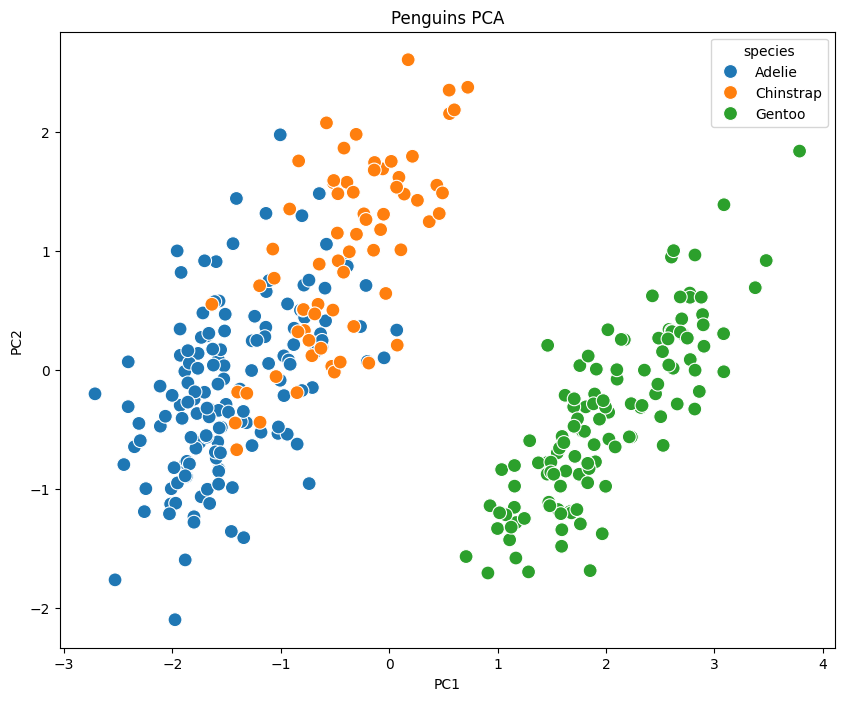

In [39]:
# PCA 결과 시각화

# 데이터프레임 생성
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)


# 종 정보 추가
pca_df["species"] = df["species"].values


# 그래프
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    s=100
)

plt.title("Penguins PCA")

plt.show()

In [ ]:
print(pca.components_)

loading = pd.DataFrame(
    pca.components_,
    columns=num_cols,
    index=["PC1","PC2"]
)

print(loading)

#pc1 => 몸무게 + 날개길이 = 덩치
#pc2 => 부리

[[ 0.45375317 -0.39904723  0.576825    0.54967471]
 [ 0.6001949   0.79616951  0.00578817  0.07646366]]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
PC1        0.453753      -0.399047           0.576825     0.549675
PC2        0.600195       0.796170           0.005788     0.076464
